# ¿Se puede *medir* girar el horizonte de un agujero negro?

Un agujero negro arrastra el espacio a su alrededor. Cualquier cosa que cruza su horizonte —sin importar cómo entró— parece girar a una misma velocidad: la del propio horizonte. Ese arrastre tiene una frecuencia exacta.

En **GW250114**, una de las fusiones de agujeros negros más ruidosas jamás detectadas, la señal trajo escondida una "onda directa" que oscila justo al doble de esa frecuencia y se apaga a un ritmo fijado por la gravedad del horizonte. La encontramos en los datos.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** *GW250114 reveals signatures of post-merger black-hole horizon* — Lu et al.
**Nature (2026)** · DOI: [10.1038/s41586-026-10696-0](https://doi.org/10.1038/s41586-026-10696-0)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-24-gw250114-horizonte-agujero-negro/notebook.ipynb)

🎬 Video: *(pendiente)*

## Qué pasó

El 14 de enero de 2025, dos detectores de LIGO (en Hanford y Livingston) registraron la fusión de dos agujeros negros de unas **34** y **32** masas solares. Chocaron y se fundieron en uno solo de unas **63** masas solares, girando sobre sí mismo a dos tercios del máximo permitido por la física.

GW250114 no es una fusión cualquiera: es de las más fuertes detectadas hasta ahora (relación señal-ruido de red ≈ 76). Esa potencia es lo que permite algo nuevo. La teoría predice que el remanente deja una firma en la onda gravitacional —una **onda directa**— que lleva escritos dos números del horizonte: a qué velocidad arrastra el espacio y con qué fuerza atrapa. Aquí buscamos esa firma en los datos públicos del evento.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
SNR_H1 = 15.8              # SNR de filtro adaptado de la onda directa (Hanford)
SNR_L1 = 17.1              # SNR de filtro adaptado de la onda directa (Livingston)
CHI_F = 0.6725             # Espín final del remanente (maxP) usado para normalizar
DOS_OMEGA_H = 0.3865       # 2·Omega_H — frecuencia de arrastre del horizonte (1/M_f)
KAPPA = 0.2127             # kappa — gravedad superficial del horizonte (1/M_f)

COLOR_DATOS = '#2563EB'    # Azul CaM — datos observados
COLOR_ALERTA = '#DC2626'   # Rojo — modelo / valor de referencia
COLOR_SEC = '#059669'      # Emerald — serie secundaria
COLOR_REF = '#D97706'      # Amber — umbral / predicción teórica
COLOR_VIO = '#7C3AED'      # Violeta

FUENTE = ('Fuente: Lu et al. (2026), Nature | '
          'Datos: release de código GW250114 (Zenodo 20017347 · 16877102)')

# ── Imports y estilo ──────────────────────────────────────────────
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# ── Carga de los cuatro datasets ──────────────────────────────────
strain = pd.read_csv('datos/strain_blanqueado.csv')      # forma de onda
snr    = pd.read_csv('datos/snr_onda_directa.csv')        # significancia
freq   = pd.read_csv('datos/frecuencia_onda_directa.csv') # huella de Kerr
rem    = pd.read_csv('datos/remanente_posterior.csv')     # el remanente

print(f'Strain:      {len(strain):>6} puntos  ({strain.tiempo_s.min():.2f} a {strain.tiempo_s.max():.2f} s)')
print(f'SNR:         {len(snr):>6} muestras del posterior')
print(f'Frecuencia:  {len(freq):>6} puntos de la onda directa')
print(f'Remanente:   {len(rem):>6} muestras del posterior')
print()
print(f'Masa final:  {rem.masa_final_source_Msun.median():.1f} M_sol  (mediana)')
print(f'Espin final: {rem.espin_final.median():.3f}')
print(f'SNR H1:      {snr.h1_filtro_adaptado.median():.2f}   SNR L1: {snr.l1_filtro_adaptado.median():.2f}')

Strain:        3277 puntos  (-0.10 a 0.30 s)
SNR:          10000 muestras del posterior
Frecuencia:    1500 puntos de la onda directa
Remanente:     8000 muestras del posterior

Masa final:  62.7 M_sol  (mediana)
Espin final: 0.676
SNR H1:      15.81   SNR L1: 17.14


## La señal

Aquí está.

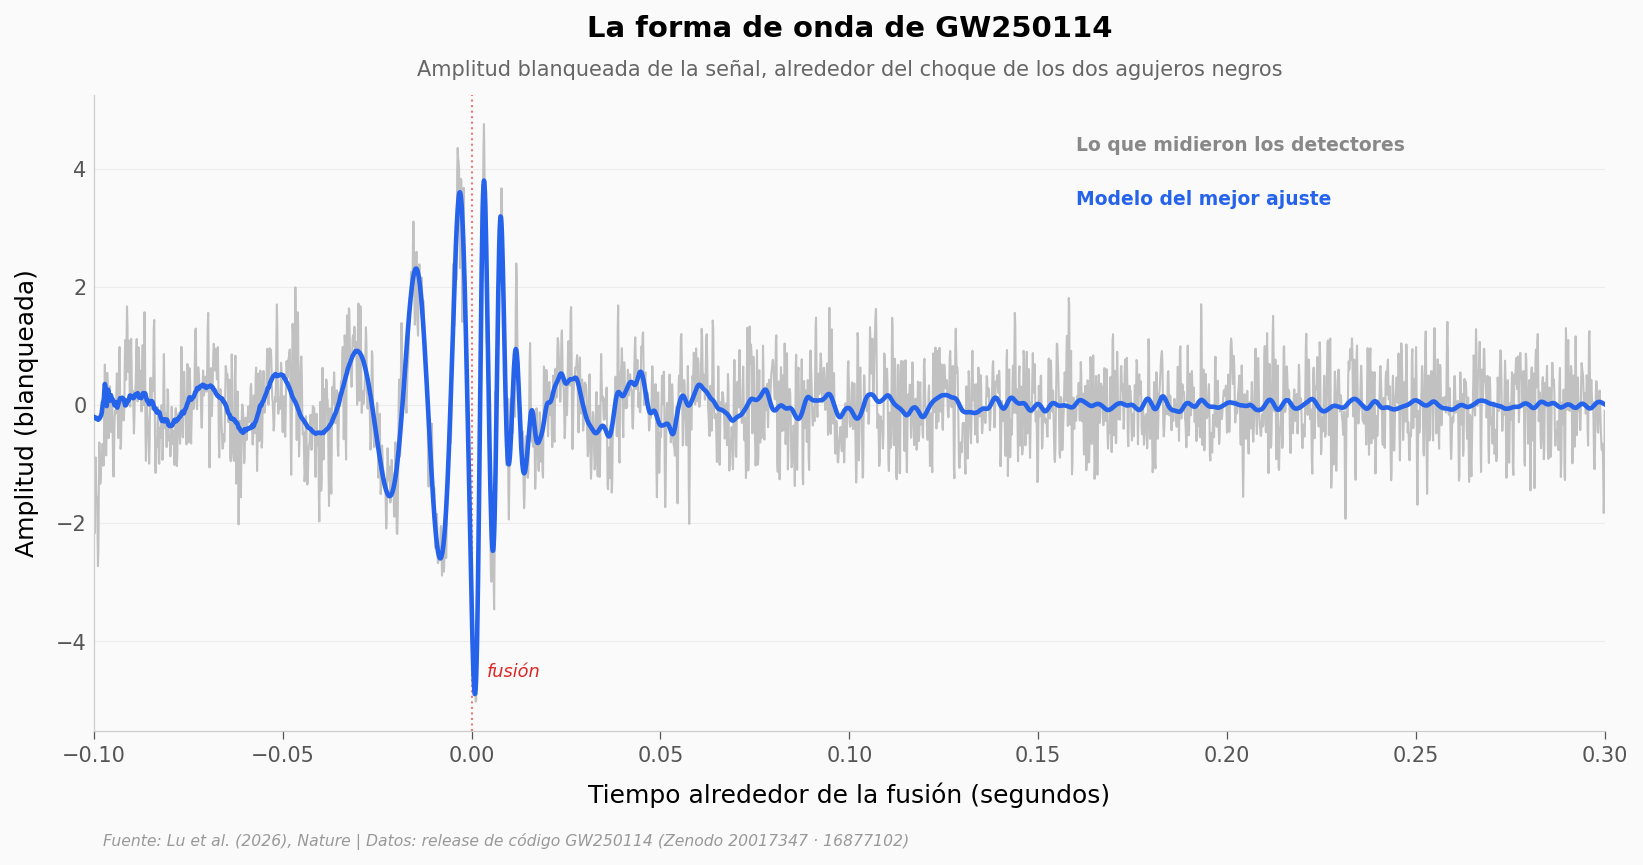

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(strain.tiempo_s, strain.observado, color='#BBBBBB', linewidth=1.0,
        alpha=0.9, zorder=2)
ax.plot(strain.tiempo_s, strain.modelo_nrsur, color=COLOR_DATOS, linewidth=2.2,
        zorder=4)

# Etiquetas inline (sin caja de leyenda)
ax.text(0.16, 4.3, 'Lo que midieron los detectores', fontsize=9,
        color='#888888', fontweight='bold', ha='left')
ax.text(0.16, 3.4, 'Modelo del mejor ajuste', fontsize=9,
        color=COLOR_DATOS, fontweight='bold', ha='left')

# Marca del instante de fusión
ax.axvline(x=0, color='#DC2626', linewidth=1.0, linestyle=':', alpha=0.6)
ax.text(0.004, -4.6, 'fusión', fontsize=8.5, color='#DC2626',
        style='italic', ha='left')

ax.set_title('La forma de onda de GW250114',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Amplitud blanqueada de la señal, alrededor del choque de los dos agujeros negros',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo alrededor de la fusión (segundos)')
ax.set_ylabel('Amplitud (blanqueada)')
ax.set_xlim(-0.1, 0.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/forma_de_onda.png', dpi=200, bbox_inches='tight')
plt.show()

La señal sube hasta el instante de la fusión y luego se apaga en fracciones de segundo: es el remanente vibrando y estabilizándose. El modelo del mejor ajuste sigue de cerca lo que midieron los detectores, incluso cuando el ruido tira de los datos.

Pero dentro de esa curva hay una parte pequeña —la onda directa— que no viene del choque en sí, sino del horizonte del agujero negro ya formado. Para verla, hay que ir a las frecuencias.

## La huella del horizonte

El horizonte se describe con dos números. Uno es **2·Ω_H**: el doble de la velocidad a la que arrastra el espacio a su alrededor (por eso todo lo que cae parece girar igual). El otro es **κ** (kappa): la gravedad superficial, que fija a qué ritmo se apaga cualquier señal que sale de ahí.

Si la onda directa viene de verdad del horizonte, su frecuencia de oscilación debería acercarse a 2·Ω_H y su ritmo de apagado a κ. Veamos los dos cocientes: si tienden a **1**, la onda lleva la huella del horizonte.

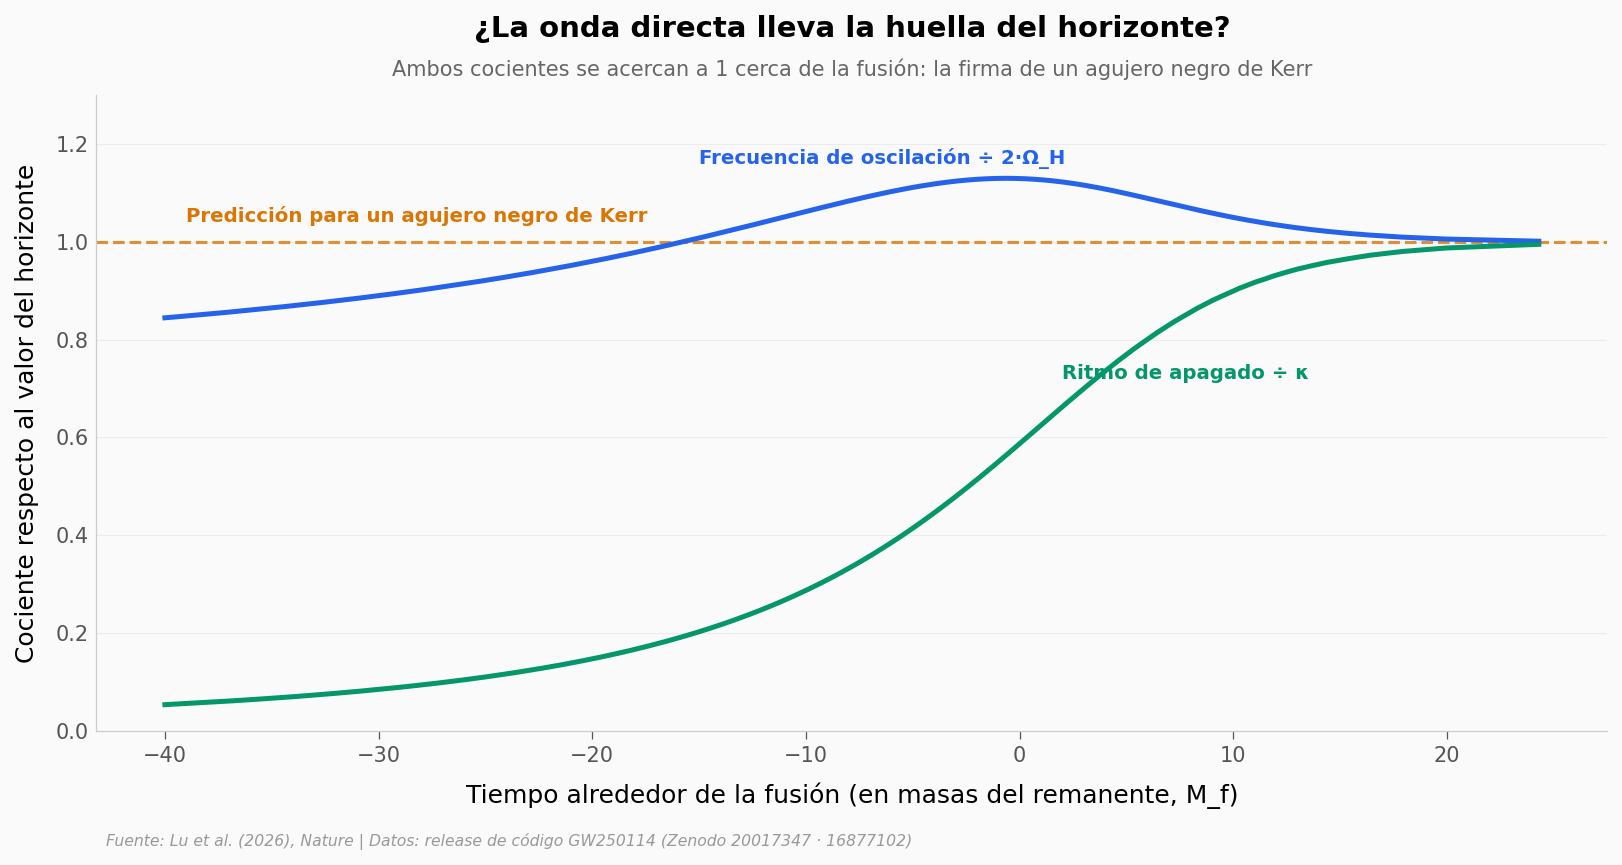

Máximo de la frecuencia ÷ 2·Ω_H:  1.13
Máximo del apagado ÷ κ:           0.99


In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.plot(freq.tiempo_Mf, freq.re_omega_sobre_2omegaH, color=COLOR_DATOS,
        linewidth=2.4, zorder=5)
ax.plot(freq.tiempo_Mf, freq.menos_im_omega_sobre_kappa, color=COLOR_SEC,
        linewidth=2.4, zorder=5)

# Línea de referencia: la predicción de Kerr es exactamente 1
ax.axhline(y=1.0, color=COLOR_REF, linewidth=1.5, linestyle='--', alpha=0.8)
ax.text(-39, 1.04, 'Predicción para un agujero negro de Kerr', fontsize=9.5,
        color=COLOR_REF, fontweight='bold', ha='left')

# Etiquetas inline
ax.text(-15, 1.16, 'Frecuencia de oscilación ÷ 2·Ω_H', fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', ha='left')
ax.text(2, 0.72, 'Ritmo de apagado ÷ κ', fontsize=9.5,
        color=COLOR_SEC, fontweight='bold', ha='left')

ax.set_title('¿La onda directa lleva la huella del horizonte?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ambos cocientes se acercan a 1 cerca de la fusión: la firma de un agujero negro de Kerr',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Tiempo alrededor de la fusión (en masas del remanente, M_f)')
ax.set_ylabel('Cociente respecto al valor del horizonte')
ax.set_ylim(0, 1.3)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/huella_horizonte.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Máximo de la frecuencia ÷ 2·Ω_H:  {freq.re_omega_sobre_2omegaH.max():.2f}')
print(f'Máximo del apagado ÷ κ:           {freq.menos_im_omega_sobre_kappa.max():.2f}')

Los dos cocientes convergen en 1 cerca del choque: la onda directa oscila a la velocidad de arrastre del horizonte y se apaga a su gravedad superficial. Son dos propiedades del horizonte que leemos directo de la onda, sin suponer de antemano qué agujero negro las produjo.

¿Y qué agujero negro fue? Los datos también reconstruyen al remanente.

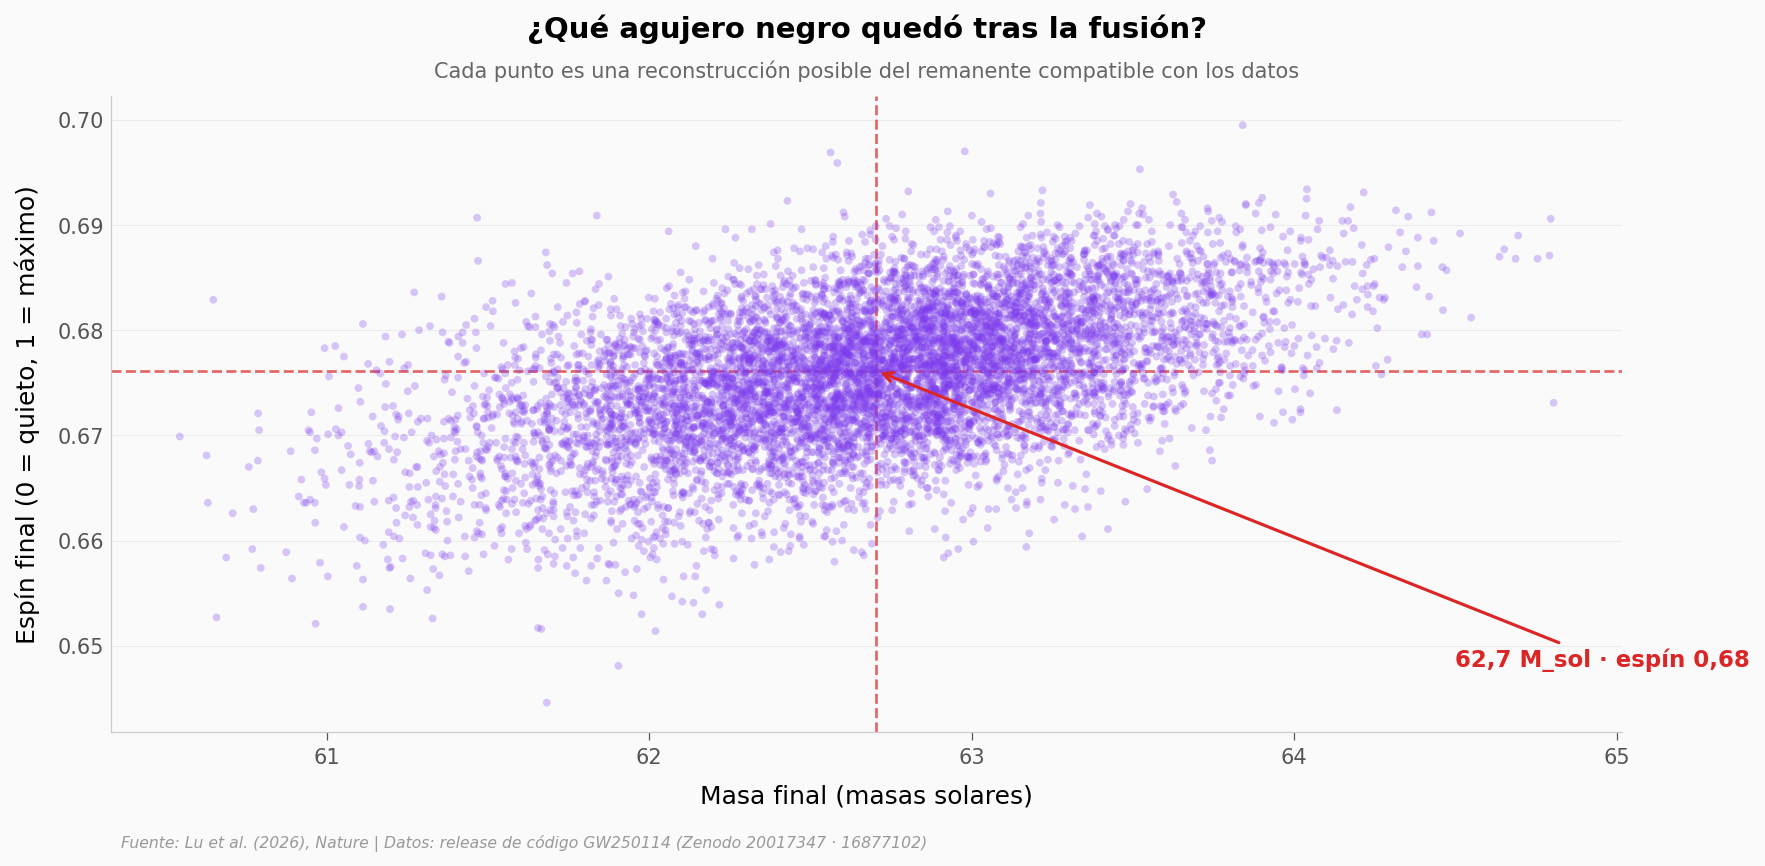

Espin final: 0.676  (90% cred.: 0.664 a 0.686)
Masa final:  62.7 M_sol  (90% cred.: 61.6 a 63.7)


In [4]:
fig, ax = plt.subplots(figsize=(13, 5.5))

ax.scatter(rem.masa_final_source_Msun, rem.espin_final, color=COLOR_VIO,
           s=14, alpha=0.28, edgecolors='none', zorder=3)

# Medianas como crosshair
m_med = rem.masa_final_source_Msun.median()
s_med = rem.espin_final.median()
m_txt = f'{m_med:.1f}'.replace('.', ',')
s_txt = f'{s_med:.2f}'.replace('.', ',')
ax.axvline(x=m_med, color=COLOR_ALERTA, linewidth=1.3, linestyle='--', alpha=0.7)
ax.axhline(y=s_med, color=COLOR_ALERTA, linewidth=1.3, linestyle='--', alpha=0.7)
ax.annotate(f'{m_txt} M_sol · espín {s_txt}',
            xy=(m_med, s_med), xytext=(64.5, 0.648),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Qué agujero negro quedó tras la fusión?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es una reconstrucción posible del remanente compatible con los datos',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Masa final (masas solares)')
ax.set_ylabel('Espín final (0 = quieto, 1 = máximo)')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/remanente.png', dpi=200, bbox_inches='tight')
plt.show()

lo, hi = rem.espin_final.quantile([0.05, 0.95])
print(f'Espin final: {s_med:.3f}  (90% cred.: {lo:.3f} a {hi:.3f})')
mlo, mhi = rem.masa_final_source_Msun.quantile([0.05, 0.95])
print(f'Masa final:  {m_med:.1f} M_sol  (90% cred.: {mlo:.1f} a {mhi:.1f})')

## ¿Qué tan segura es la detección?

La onda directa es apenas una fracción de una señal enorme. Si fuera ruido, su significancia debería rondar el cero. ¿Dónde cae en realidad?

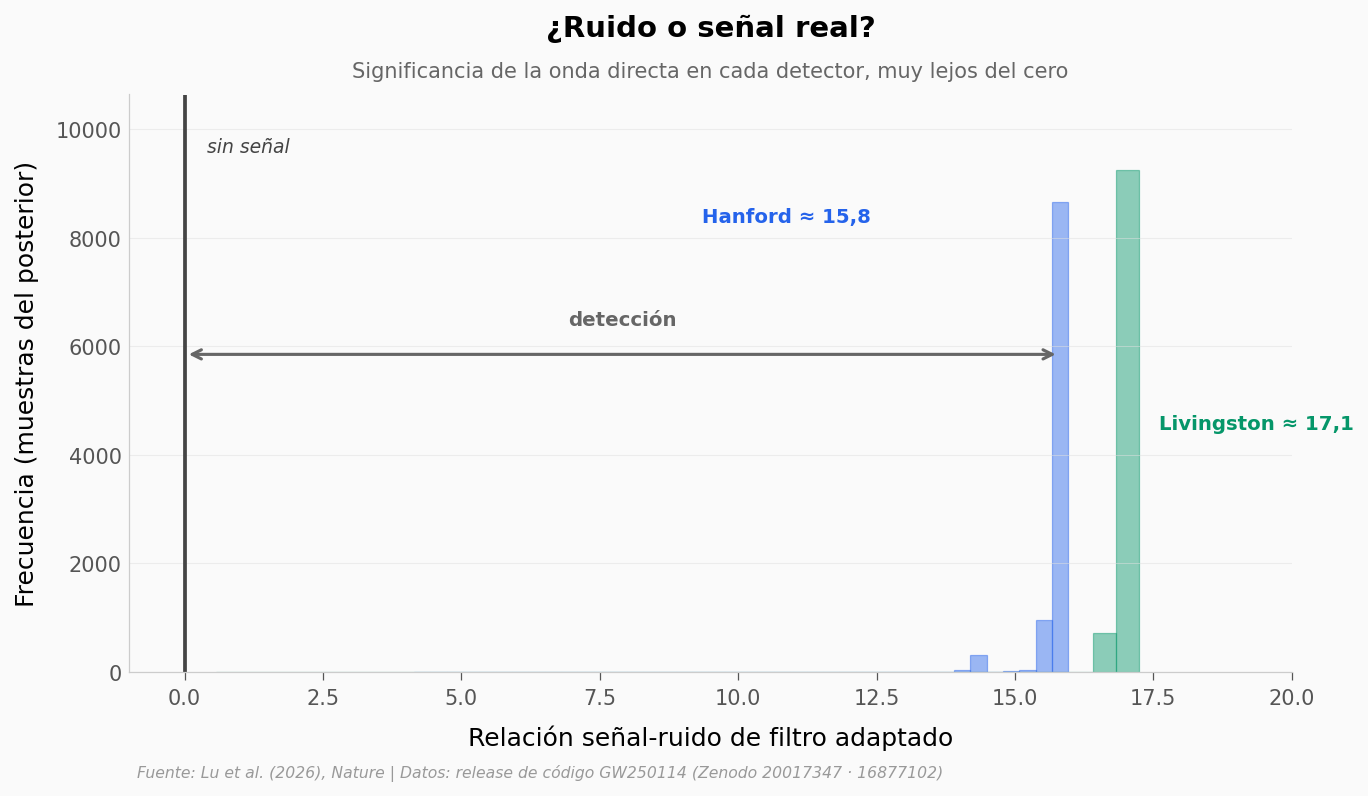

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

# Recortar la cola de valores negativos raros para centrar el grueso del posterior
h1 = snr.h1_filtro_adaptado[snr.h1_filtro_adaptado > 0]
l1 = snr.l1_filtro_adaptado[snr.l1_filtro_adaptado > 0]

ax.hist(h1, bins=40, color=COLOR_DATOS, alpha=0.45,
        edgecolor=COLOR_DATOS, linewidth=0.6)
ax.hist(l1, bins=40, color=COLOR_SEC, alpha=0.45,
        edgecolor=COLOR_SEC, linewidth=0.6)

n_max = max(np.histogram(h1, bins=40)[0].max(),
            np.histogram(l1, bins=40)[0].max())
y_max = n_max * 1.15
ax.set_ylim(0, y_max)

# Línea de la hipótesis nula: sin señal, SNR ≈ 0
ax.axvline(x=0, color='#444444', linewidth=1.8)
ax.text(0.4, y_max * 0.9, 'sin señal', fontsize=9, color='#444444',
        style='italic', ha='left')

# Flecha bidireccional: distancia del cero al grueso de la detección
ax.annotate('', xy=(snr.h1_filtro_adaptado.median(), y_max * 0.55),
            xytext=(0, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(SNR_H1 / 2, y_max * 0.60, 'detección', fontsize=9.5,
        color='#666666', ha='center', fontweight='bold')

ax.text(12.4, y_max * 0.78, f"Hanford ≈ {str(SNR_H1).replace('.', ',')}", fontsize=9.5,
        color=COLOR_DATOS, fontweight='bold', ha='right')
ax.text(17.6, y_max * 0.42, f"Livingston ≈ {str(SNR_L1).replace('.', ',')}", fontsize=9.5,
        color=COLOR_SEC, fontweight='bold', ha='left')

ax.set_title('¿Ruido o señal real?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Significancia de la onda directa en cada detector, muy lejos del cero',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Relación señal-ruido de filtro adaptado')
ax.set_ylabel('Frecuencia (muestras del posterior)')
ax.set_xlim(-1, 20)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/significancia.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| La onda directa se detecta con SNR ≈ 15,8 (Hanford) y ≈ 17,1 (Livingston) | ✅ | Mediana del posterior descargado: 15,81 (H1) y 17,14 (L1), a dos decimales del valor del paper. El grueso de la distribución cae muy lejos del cero. |
| El remanente tiene ≈ 63 masas solares y espín ≈ 0,68 | ✅ | Mediana del posterior: 62,7 M_sol (90% cred. 61,6–63,7) y espín 0,68 (90% cred. 0,66–0,69). |
| La onda directa oscila cerca de 2·Ω_H y se apaga al ritmo de κ | ✅ | Los dos cocientes se acercan a 1 cerca de la fusión (máximos 1,13 y 0,99): la firma esperada del horizonte. |
| Es la primera evidencia observacional de este tipo | ⚠️ | El paper la enmarca como *primera evidencia* de una onda directa; una detección de su clase, aún no repetida en muchos eventos. |

> **Limitaciones:** GW250114 es un solo evento, de los más fuertes registrados —lo que hace visible una onda tan tenue—. La onda directa es una fracción pequeña de una señal enorme, así que su medición depende de esa potencia excepcional. Los cocientes de la huella provienen del modelo analítico del paper normalizado con el espín del remanente (χ_f = 0,6725), no de una medición independiente del horizonte. Trabajamos con muestras submuestreadas de los posteriores publicados, no con la cadena completa.

## Ahora tú

1. **¿Cuánto pesa la asimetría?** El intervalo de credibilidad del SNR no es simétrico. ¿Qué porcentaje de las muestras del posterior de Hanford cae por debajo de 10? *(pista: `(snr.h1_filtro_adaptado < 10).mean() * 100`)*

2. **¿Cuánta energía se fue en ondas?** Las masas de los dos progenitores suman más que el remanente. ¿Cuántas masas solares "faltan" y se convirtieron en ondas gravitacionales? *(pista: `rem.masa_1_source_Msun + rem.masa_2_source_Msun - rem.masa_final_source_Msun`)*

3. **¿Cuándo cruza la huella el valor 1?** En la gráfica de la huella, ¿en qué instante `tiempo_Mf` el cociente de la frecuencia pasa por primera vez de 1? *(pista: filtra `freq[freq.re_omega_sobre_2omegaH >= 1]` y mira el primer `tiempo_Mf`)*

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Cuánta masa se convirtió en ondas gravitacionales?
masa_perdida = (rem.masa_1_source_Msun + rem.masa_2_source_Msun
                - rem.masa_final_source_Msun)

med = masa_perdida.median()
lo, hi = masa_perdida.quantile([0.05, 0.95])
print(f'Masa radiada como ondas gravitacionales: {med:.2f} M_sol')
print(f'  (90% credibilidad: {lo:.2f} a {hi:.2f} M_sol)')
print()
print(f'Equivale a {med / rem.masa_final_source_Msun.median() * 100:.1f}% de la masa del remanente,')
print('liberada en fracciones de segundo, en su mayoría en el instante de la fusión.')

Masa radiada como ondas gravitacionales: 3.12 M_sol
  (90% credibilidad: 3.02 a 3.22 M_sol)

Equivale a 5.0% de la masa del remanente,
liberada en fracciones de segundo, en su mayoría en el instante de la fusión.


## Créditos y reproducibilidad

Este notebook reconstruye resultados de GW250114 a partir de los posteriores y modelos publicados con el paper. Todo el código es reproducible: cambia los valores de la celda de configuración y vuelve a ejecutar.

- **Datos:** release de código de GW250114 (Zenodo [20017347](https://zenodo.org/records/20017347)) y scripts de figuras del descubrimiento (Zenodo [16877102](https://zenodo.org/records/16877102)).
- **Licencia:** los datos originales conservan la licencia de sus repositorios; este notebook, MIT.
- **Repo:** [Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)

## Fuentes

**Paper**: [GW250114 reveals signatures of post-merger black-hole horizon](https://doi.org/10.1038/s41586-026-10696-0)  
*Nature, 2026-06-24 · paywall*

**Dataset canónico**: [Release de código GW250114](https://zenodo.org/records/20017347)  
*Strain, posterior de SNR y frecuencia de la onda directa*

**Dataset canónico**: [Scripts de figuras del descubrimiento](https://zenodo.org/records/16877102)  
*Posterior NRSur7dq4 del remanente y los progenitores*

*13 afirmaciones del notebook verificadas contra estas fuentes*